In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time
import gymnasium as gym

In [33]:
class GridWorld:
    def __init__(self, size=4, stochastic=False):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.stochastic = stochastic
        self.terminal_states = [0, self.n_states - 1]

        self.actions = {
            0: (-1, 0),
            1: (0, 1),
            2: (1, 0),
            3: (0, -1)
        }

    def state_to_pos(self, s):
        return divmod(s, self.size)

    def pos_to_state(self, pos):
        return pos[0] * self.size + pos[1]

    def get_transitions(self):
        P = {s: {a: [] for a in range(self.n_actions)} for s in range(self.n_states)}

        for s in range(self.n_states):
            if s in self.terminal_states:
                for a in range(self.n_actions):
                    P[s][a] = [(1.0, s, 0)]
                continue

            for a in range(self.n_actions):
                if self.stochastic:
                    probs = [(0.8, a), (0.1, (a+1)%4), (0.1, (a-1)%4)]
                else:
                    probs = [(1.0, a)]

                for prob, act in probs:
                    r, c = self.state_to_pos(s)
                    dr, dc = self.actions[act]

                    nr = max(0, min(self.size-1, r + dr))
                    nc = max(0, min(self.size-1, c + dc))

                    ns = self.pos_to_state((nr, nc))
                    reward = -1

                    P[s][a].append((prob, ns, reward))

        return P

In [34]:
def get_transition_values(transition):
    prob = transition[0]
    next_s = transition[1]
    reward = transition[2]
    return prob, next_s, reward

In [35]:
def policy_evaluation(policy, P, gamma=0.99, theta=1e-6):
    V = np.zeros(len(policy))

    while True:
        delta = 0
        new_V = np.copy(V)

        for s in range(len(policy)):
            v = 0
            for a, action_prob in enumerate(policy[s]):
                for t in P[s][a]:
                    prob, next_s, reward = get_transition_values(t)
                    v += action_prob * prob * (reward + gamma * V[next_s])

            new_V[s] = v
            delta = max(delta, abs(V[s] - v))

        V = new_V

        if delta < theta:
            break

    return V

In [36]:
def policy_iteration(P, n_states, n_actions, gamma=0.99):
    policy = np.ones([n_states, n_actions]) / n_actions

    iterations = 0
    start = time.time()

    while True:
        V = policy_evaluation(policy, P, gamma)

        stable = True

        for s in range(n_states):
            old_action = np.argmax(policy[s])

            q_values = np.zeros(n_actions)
            for a in range(n_actions):
                for t in P[s][a]:
                    prob, next_s, reward = get_transition_values(t)
                    q_values[a] += prob * (reward + gamma * V[next_s])

            best_action = np.argmax(q_values)
            policy[s] = np.eye(n_actions)[best_action]

            if old_action != best_action:
                stable = False

        iterations += 1
        if stable:
            break

    return policy, V, iterations, time.time() - start

In [37]:
def value_iteration_debug(P, n_states, n_actions, gamma=0.99, theta=1e-6):
    V = np.zeros(n_states)

    deltas = []
    history = []
    start = time.time()

    while True:
        delta = 0
        new_V = np.copy(V)

        for s in range(n_states):
            q_values = np.zeros(n_actions)

            for a in range(n_actions):
                for t in P[s][a]:
                    prob, next_s, reward = get_transition_values(t)
                    q_values[a] += prob * (reward + gamma * V[next_s])

            new_V[s] = max(q_values)
            delta = max(delta, abs(V[s] - new_V[s]))

        V = new_V
        deltas.append(delta)
        history.append(V.copy())

        if delta < theta:
            break

    policy = extract_policy(P, V, n_states, n_actions, gamma)

    return policy, V, deltas, history, time.time() - start

In [39]:
def extract_policy(P, V, n_states, n_actions, gamma):
    policy = np.zeros((n_states, n_actions))

    for s in range(n_states):
        q_values = np.zeros(n_actions)

        for a in range(n_actions):
            for t in P[s][a]:
                prob, next_s, reward = get_transition_values(t)
                q_values[a] += prob * (reward + gamma * V[next_s])

        best_action = np.argmax(q_values)
        policy[s] = np.eye(n_actions)[best_action]

    return policy

In [40]:
def plot_value(V, size, title):
    plt.imshow(V.reshape(size, size), cmap='coolwarm')
    plt.colorbar()
    plt.title(title)
    plt.show()


def plot_policy(policy, size, title):
    X, Y = np.meshgrid(range(size), range(size))

    U = np.zeros_like(X, dtype=float)
    Vv = np.zeros_like(Y, dtype=float)

    direction_map = {
        0: (0, -1),
        1: (1, 0),
        2: (0, 1),
        3: (-1, 0)
    }

    for s in range(size * size):
        r, c = divmod(s, size)
        a = np.argmax(policy[s])
        U[r, c], Vv[r, c] = direction_map[a]

    plt.quiver(X, Y, U, Vv)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()

In [41]:
def plot_convergence(deltas, title):
    plt.plot(deltas)
    plt.xlabel("Iterations")
    plt.ylabel("Delta")
    plt.title(title)
    plt.show()


def show_value_iterations(history, size):
    for i, V in enumerate(history[:4]):
        plt.imshow(V.reshape(size, size), cmap='coolwarm')
        plt.title(f"Iteration {i+1}")
        plt.colorbar()
        plt.show()

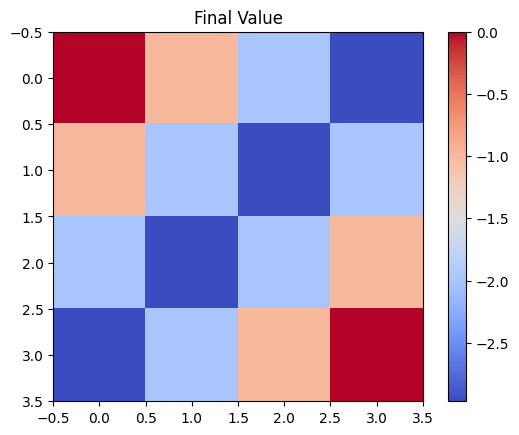

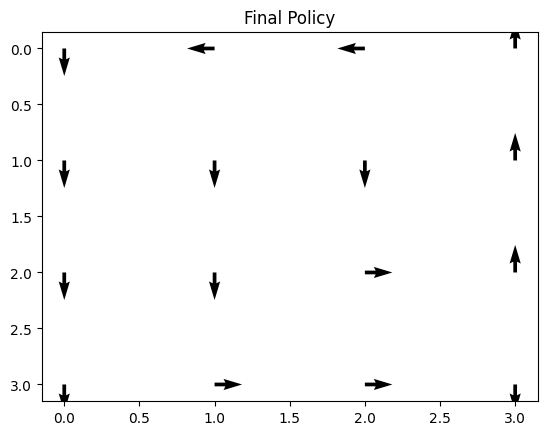

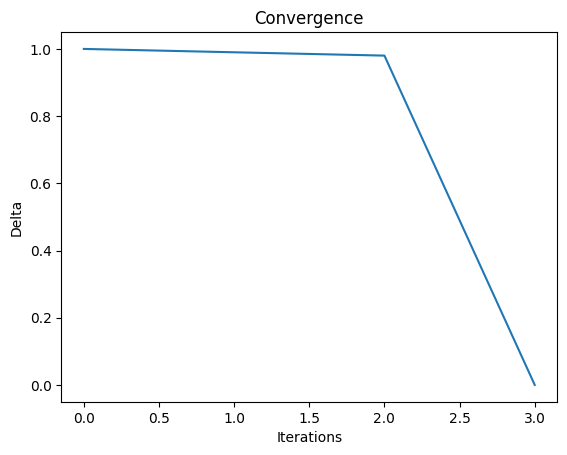

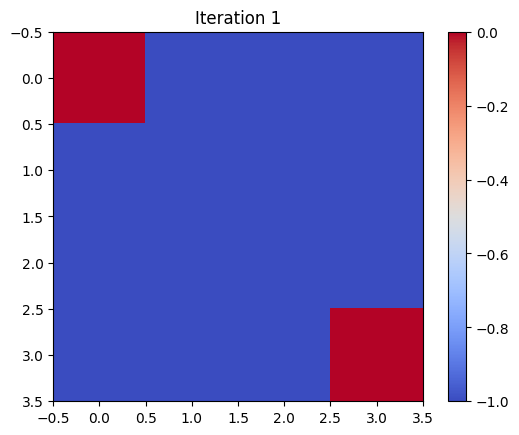

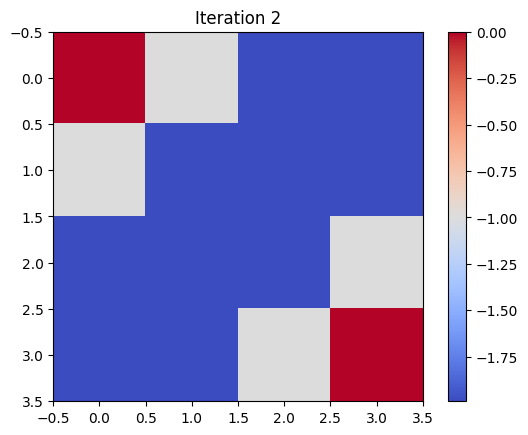

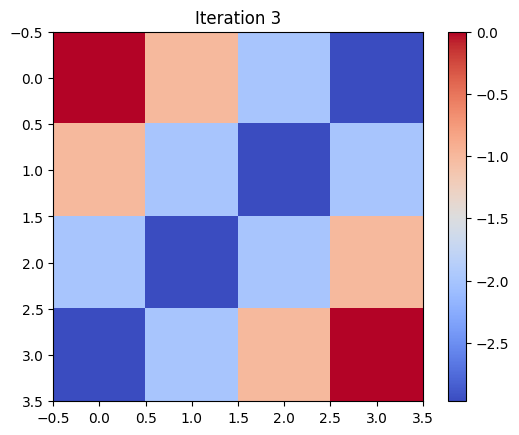

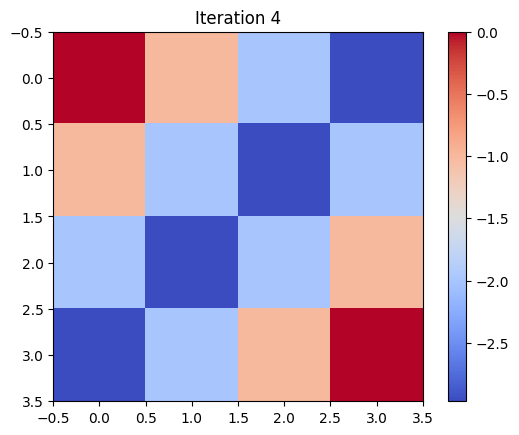

In [42]:
env = GridWorld(size=4, stochastic=False)
P = env.get_transitions()

policy, V, deltas, history, t = value_iteration_debug(P, env.n_states, env.n_actions)

plot_value(V, 4, "Final Value")
plot_policy(policy, 4, "Final Policy")
plot_convergence(deltas, "Convergence")
show_value_iterations(history, 4)

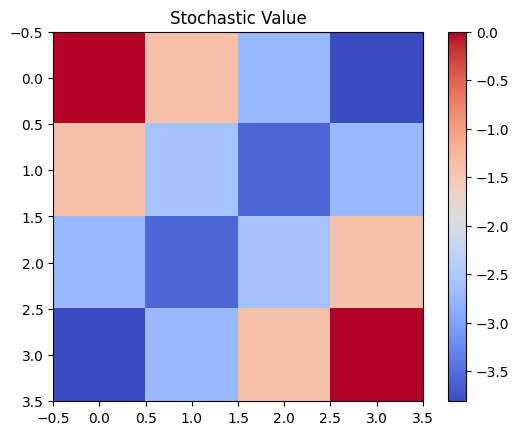

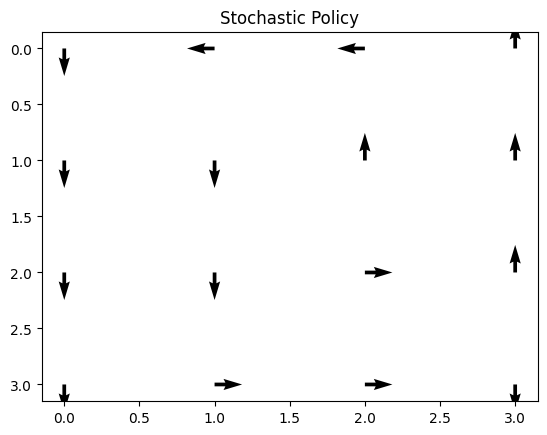

In [43]:
env = GridWorld(size=4, stochastic=True)
P = env.get_transitions()

policy, V, deltas, history, t = value_iteration_debug(P, env.n_states, env.n_actions)

plot_value(V, 4, "Stochastic Value")
plot_policy(policy, 4, "Stochastic Policy")

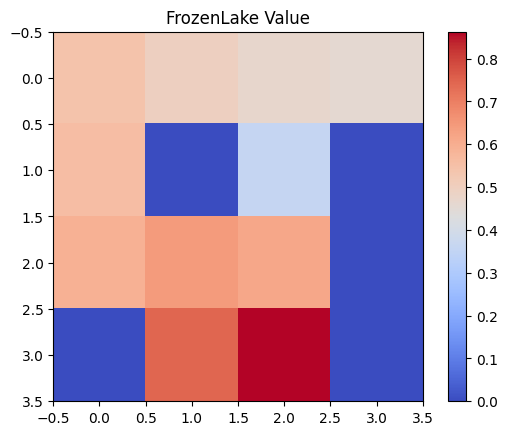

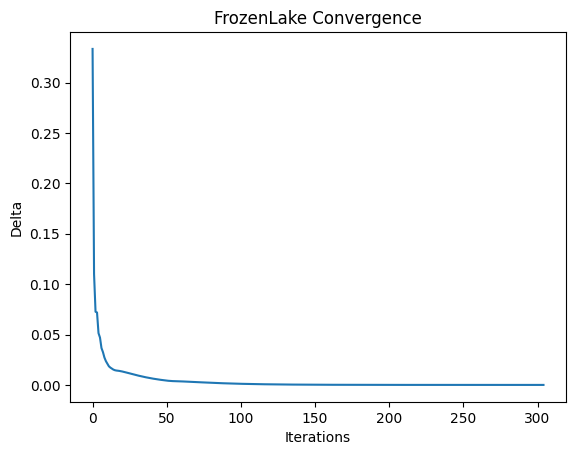

In [44]:
env = gym.make("FrozenLake-v1", is_slippery=True)
P = env.unwrapped.P

n_states = env.observation_space.n
n_actions = env.action_space.n

policy, V, deltas, history, t = value_iteration_debug(P, n_states, n_actions)

plot_value(V, 4, "FrozenLake Value")
plot_convergence(deltas, "FrozenLake Convergence")